In [7]:
import os

OUT = "charts"
os.makedirs(OUT, exist_ok=True)

In [1]:
"""
ApexPlanet Data Analytics Internship - Task 2
PART 1: Descriptive Statistics & Univariate Analysis
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'
COLORS = ['#2E75B6', '#F4B942', '#70AD47', '#C0504D', '#8064A2', '#4BACC6']

df = pd.read_csv('cleaned_dataset.csv')
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Order_Date_Year,Order_Date_Month,Order_Date_Day,Revenue_Category,Age_Group,Purchase_Month_Name,Order_Day_Of_Week,Customer_Sales_Category
0,Ord100002,2025-02-25,Cust5529,Customer_227,30,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,2025,2,25,Low_Revenue,Young Adult,February,Tuesday,Low_Spender
1,Ord100003,2025-10-14,Cust3127,Customer_182,63,Male,Bengaluru,Book,Education,5,27906.16,139530.80,2025,10,14,Medium_Revenue,Senior,October,Tuesday,Medium_Spender
2,Ord100004,2025-05-13,Cust8887,Customer_487,62,Female,Bengaluru,Book,Education,8,37491.06,299928.48,2025,5,13,High_Revenue,Senior,May,Tuesday,High_Spender
3,Ord100005,2025-12-02,Cust2515,Customer_470,65,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,2025,12,2,High_Revenue,Senior,December,Tuesday,High_Spender
4,Ord100006,2025-11-20,Cust4796,Customer_380,44,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,2025,11,20,Medium_Revenue,Adult,November,Thursday,Medium_Spender


In [4]:
# ─────────────────────────────────────────────
# NUMERICAL SUMMARY STATISTICS
# ─────────────────────────────────────────────
print("=" * 60)
print("NUMERICAL SUMMARY STATISTICS")
print("=" * 60)
num_cols = ['Age', 'Quantity', 'Unit_Price', 'Total_Sales']
summary = df[num_cols].describe().T
summary['skew'] = df[num_cols].skew()
summary['mode'] = df[num_cols].mode().iloc[0]
print(summary.round(2))

NUMERICAL SUMMARY STATISTICS
              count       mean        std     min       25%        50%  \
Age          1000.0      41.35      13.68   18.00     30.00      41.00   
Quantity     1000.0       5.44       2.84    1.00      3.00       5.00   
Unit_Price   1000.0   25486.78   14179.40  145.78  13895.72   25398.74   
Total_Sales  1000.0  139399.44  114100.05  437.34  47066.63  108594.02   

                   75%        max  skew    mode  
Age              53.00      65.00  0.04   41.00  
Quantity          8.00      10.00  0.06    4.00  
Unit_Price    37512.38   49997.53 -0.03  145.78  
Total_Sales  203722.88  493677.50  0.99  437.34  


In [6]:
# ─────────────────────────────────────────────
# CATEGORICAL SUMMARY STATISTICS
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("CATEGORICAL VALUE COUNTS")
print("=" * 60)
cat_cols = ['Gender', 'City', 'Category', 'Product', 'Age_Group', 'Revenue_Category']
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


CATEGORICAL VALUE COUNTS

--- Gender ---
Gender
Male      511
Female    489
Name: count, dtype: int64

--- City ---
City
Patna        148
Kolkata      133
Mumbai       131
Hyderabad    125
Delhi        125
Bengaluru    122
Gaya         117
Pune          99
Name: count, dtype: int64

--- Category ---
Category
Electronics    354
Education      178
Furniture      159
Fashion        156
Grocery        153
Name: count, dtype: int64

--- Product ---
Product
Mobile    184
Book      178
Laptop    170
Chair     159
Shoes     156
Rice      153
Name: count, dtype: int64

--- Age_Group ---
Age_Group
Adult          425
Young Adult    361
Senior         198
Youth           16
Name: count, dtype: int64

--- Revenue_Category ---
Revenue_Category
High_Revenue      340
Low_Revenue       330
Medium_Revenue    330
Name: count, dtype: int64


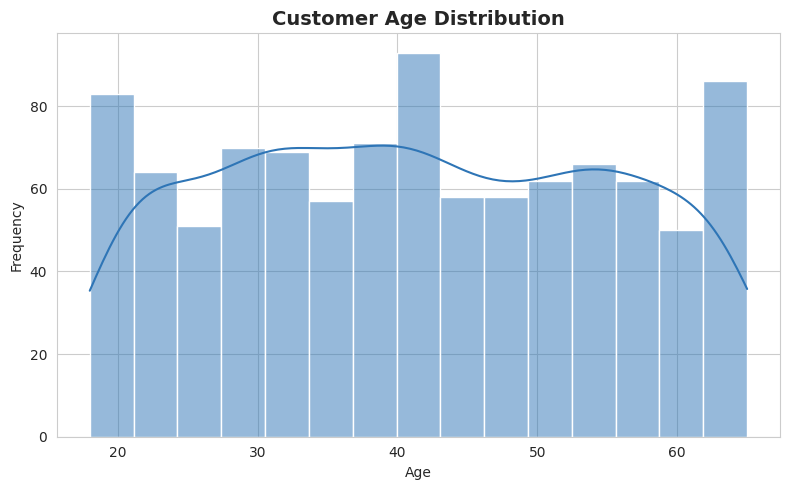

In [9]:
# ─────────────────────────────────────────────
# CHART 1: Age Distribution (Histogram)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df['Age'], bins=15, kde=True, color=COLORS[0], ax=ax)
ax.set_title('Customer Age Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Age'); ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('01_age_distribution.png', dpi=150)
plt.show()
plt.close()


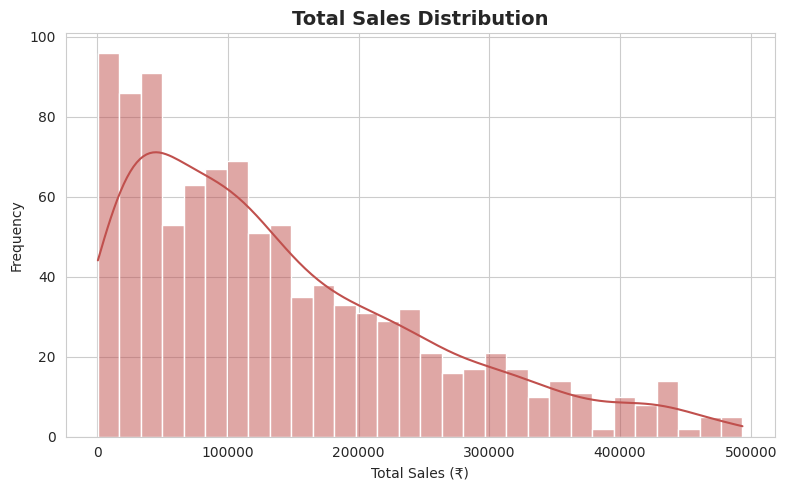

In [10]:
# ─────────────────────────────────────────────
# CHART 2: Total_Sales Distribution (Histogram)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df['Total_Sales'], bins=30, kde=True, color=COLORS[3], ax=ax)
ax.set_title('Total Sales Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Sales (₹)'); ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('02_sales_distribution.png', dpi=150)
plt.show()
plt.close()

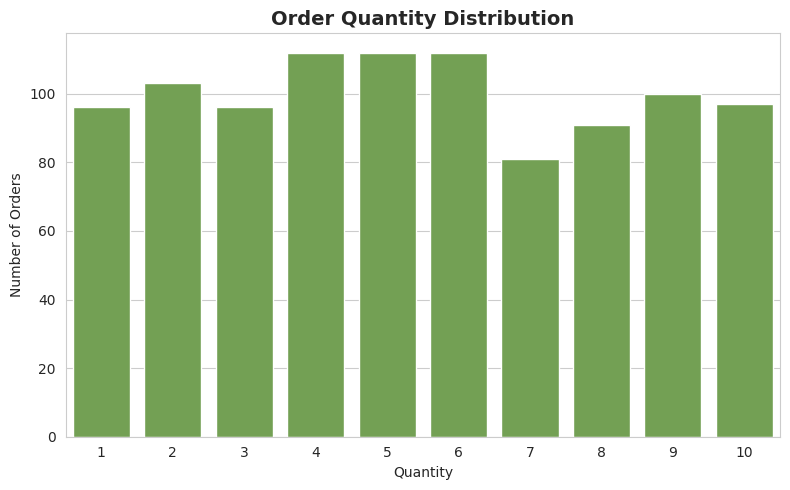

In [11]:
# ─────────────────────────────────────────────
# CHART 3: Quantity Distribution
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(x='Quantity', data=df, color=COLORS[2], ax=ax)
ax.set_title('Order Quantity Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Quantity'); ax.set_ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('03_quantity_distribution.png', dpi=150)
plt.show()
plt.close()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_26536\1605008022.py:6: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.barplot(x=cat_sales.index, y=cat_sales.values, hue=cat_sales.index, palette=COLORS, ax=ax, legend=False)


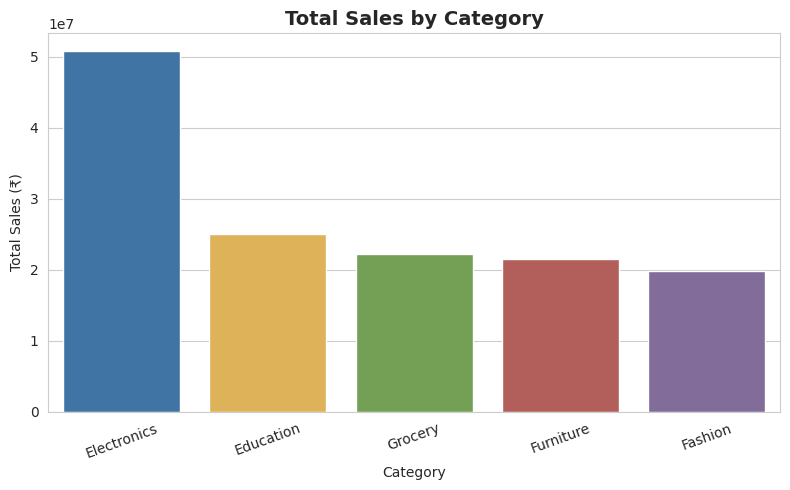

In [13]:
# ─────────────────────────────────────────────
# CHART 4: Sales by Category (Bar Chart)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
cat_sales = df.groupby('Category')['Total_Sales'].sum().sort_values(ascending=False)
sns.barplot(x=cat_sales.index, y=cat_sales.values, hue=cat_sales.index, palette=COLORS, ax=ax, legend=False)
ax.set_title('Total Sales by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category'); ax.set_ylabel('Total Sales (₹)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()
plt.savefig('04_sales_by_category.png', dpi=150)
plt.close()


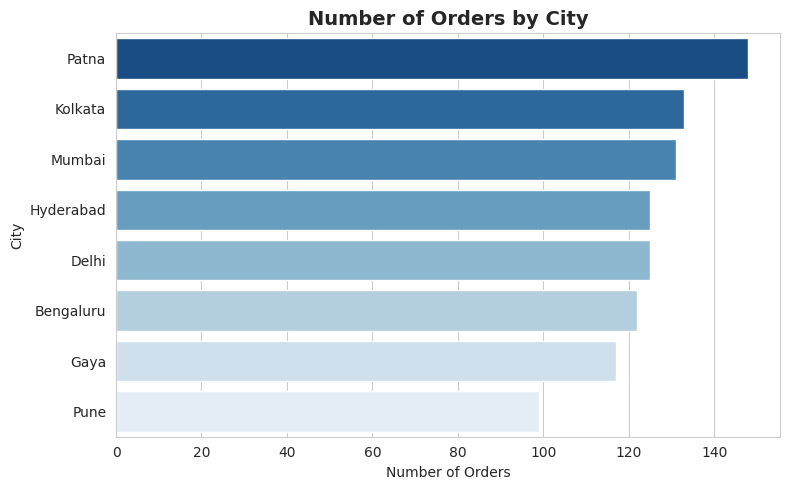

In [14]:
# ─────────────────────────────────────────────
# CHART 5: Orders by City (Bar Chart)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
city_orders = df['City'].value_counts()
sns.barplot(x=city_orders.values, y=city_orders.index, hue=city_orders.index, palette='Blues_r', ax=ax, legend=False)
ax.set_title('Number of Orders by City', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Orders'); ax.set_ylabel('City')
plt.tight_layout()
plt.savefig('05_orders_by_city.png', dpi=150)
plt.show()
plt.close()

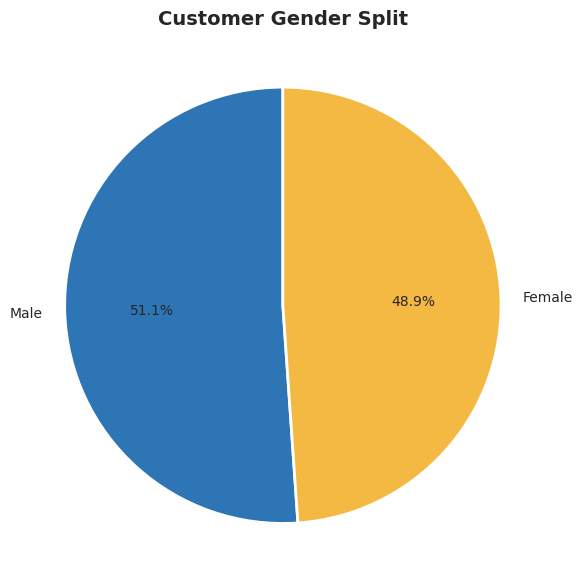

In [15]:
# ─────────────────────────────────────────────
# CHART 6: Gender Split (Pie Chart)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
gender_counts = df['Gender'].value_counts()
ax.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
       colors=[COLORS[0], COLORS[1]], startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Customer Gender Split', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('06_gender_split.png', dpi=150)
plt.show()
plt.close()

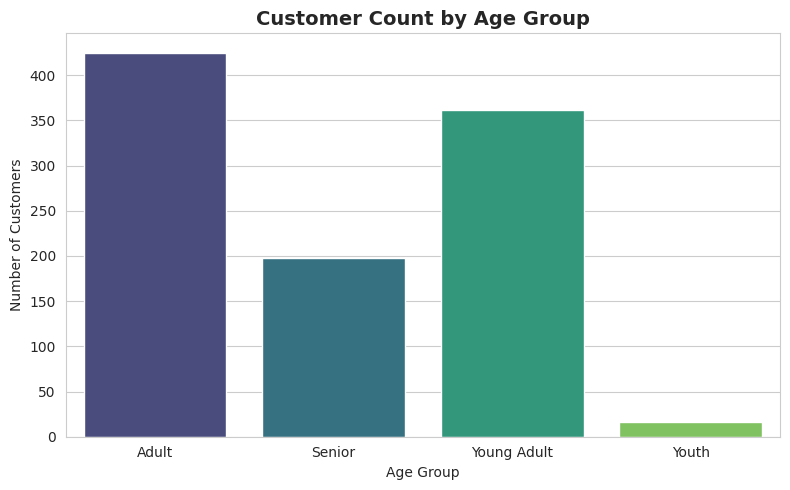

In [16]:
# ─────────────────────────────────────────────
# CHART 7: Age Group Distribution (Bar)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
age_grp = df['Age_Group'].value_counts().sort_index()
sns.barplot(x=age_grp.index, y=age_grp.values, hue=age_grp.index, palette='viridis', ax=ax, legend=False)
ax.set_title('Customer Count by Age Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group'); ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('07_age_group_distribution.png', dpi=150)
plt.show()
plt.close()

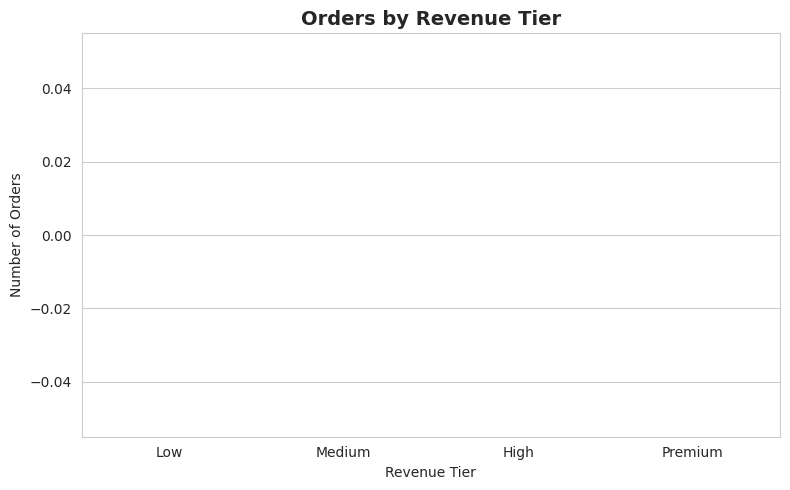

In [18]:
# ─────────────────────────────────────────────
# CHART 8: Revenue Tier Split (Bar)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
tier_order = ['Low', 'Medium', 'High', 'Premium']
tier_counts = df['Revenue_Category'].value_counts().reindex(tier_order)
sns.barplot(x=tier_counts.index, y=tier_counts.values, hue=tier_counts.index, palette='YlOrRd', ax=ax, legend=False)
ax.set_title('Orders by Revenue Tier', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue Tier'); ax.set_ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('08_revenue_tier.png', dpi=150)
plt.show()
plt.close()

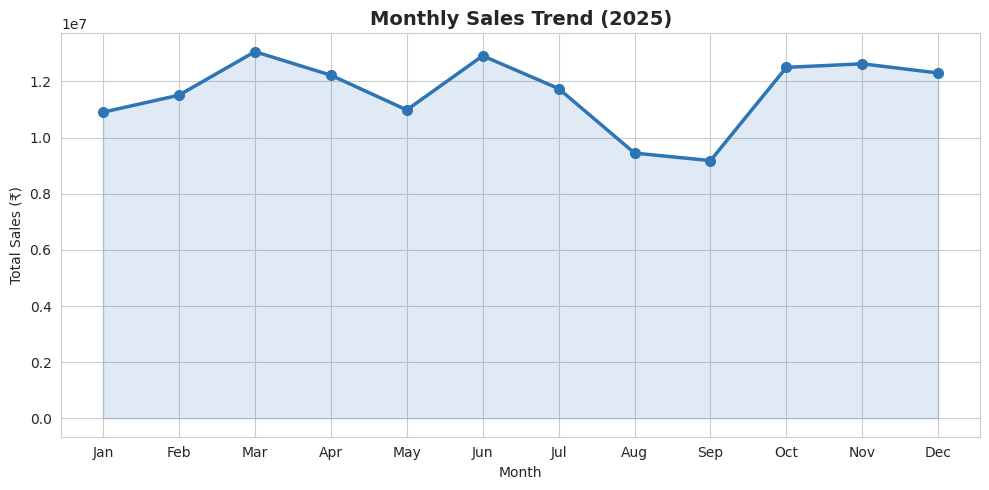

In [21]:

# ─────────────────────────────────────────────
# CHART 9: Monthly Sales Trend (Line Chart)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
monthly = df.groupby('Order_Date_Month')['Total_Sales'].sum().sort_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax.plot(month_names[:len(monthly)], monthly.values, marker='o', color=COLORS[0], linewidth=2.5, markersize=7)
ax.fill_between(range(len(monthly)), monthly.values, alpha=0.15, color=COLORS[0])
ax.set_title('Monthly Sales Trend (2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Total Sales (₹)')
plt.tight_layout()
plt.savefig('09_monthly_sales_trend.png', dpi=150)
plt.show()
plt.close()


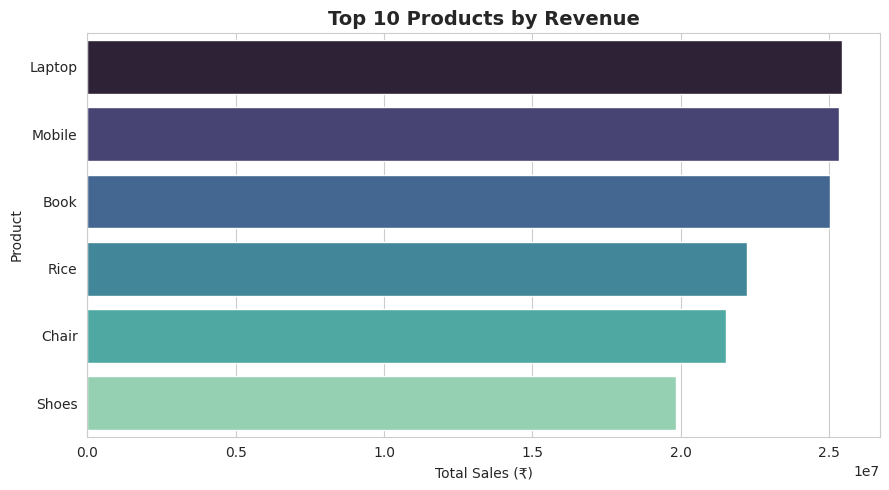

In [22]:
# ─────────────────────────────────────────────
# CHART 10: Top 10 Products by Revenue
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
top_products = df.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, palette='mako', ax=ax, legend=False)
ax.set_title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Sales (₹)'); ax.set_ylabel('Product')
plt.tight_layout()
plt.savefig('10_top_products.png', dpi=150)
plt.show()
plt.close()